In [1]:
import h5py
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("All libraries loaded!")

TensorFlow version: 2.21.0
All libraries loaded!


In [2]:
import h5py
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

EQ_HDF5     = r'chunk2\chunk2.hdf5'
EQ_CSV      = r'chunk2\chunk2.csv'
WAVE_LENGTH = 6000    # full 60-second waveform
N_SAMPLES   = 2000

def load_stead_regression(hdf5_path, csv_path, n_samples):
    """
    Load earthquake waveforms with magnitude as the label.
    Regression task — predict a number, not 0/1.
    """
    df = pd.read_csv(csv_path, low_memory=False)

    # Need both P-arrival AND magnitude to be present
    df = df[
        df['p_arrival_sample'].notna() &
        df['source_magnitude'].notna()
    ].reset_index(drop=True)

    print(f"Valid records: {len(df)}")
    print(f"Magnitude range: {df['source_magnitude'].min():.1f}"
          f" to {df['source_magnitude'].max():.1f}")
    print(f"Magnitude mean : {df['source_magnitude'].mean():.2f}")

    df = df.sample(n=min(n_samples, len(df)), random_state=42)

    X, y = [], []

    with h5py.File(hdf5_path, 'r') as f:
        for _, row in df.iterrows():
            try:
                trace_name = row['trace_name']
                magnitude  = float(row['source_magnitude'])

                waveform = f['data'][trace_name][:]   # (6000, 3)

                # Use vertical channel only — same as classification model
                channel = waveform[:, 2].astype(np.float32)

                # Normalize
                std = np.std(channel)
                if std > 0:
                    channel = channel / std

                X.append(channel)
                y.append(magnitude)

            except Exception:
                continue

    X = np.array(X)[..., np.newaxis]   # shape: (N, 6000, 1)
    y = np.array(y)                     # shape: (N,) — magnitude values

    print(f"\nLoaded       : {len(X)} samples")
    print(f"Input shape  : {X.shape}")
    print(f"Label shape  : {y.shape}")
    print(f"Label example: {y[:5]}")   # should be magnitude numbers

    return X, y

X, y = load_stead_regression(EQ_HDF5, EQ_CSV, N_SAMPLES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Valid records: 200000
Magnitude range: -0.1 to 6.5
Magnitude mean : 1.33

Loaded       : 2000 samples
Input shape  : (2000, 6000, 1)
Label shape  : (2000,)
Label example: [0.01 4.4  1.03 2.04 3.7 ]

Train: 1600, Test: 400


In [3]:
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Input shape      : {X_train.shape}")

Training samples : 1600
Test samples     : 400
Input shape      : (1600, 6000, 1)


In [10]:
import tensorflow as tf
import numpy as np

# Fix random seed so results are reproducible every run
tf.random.set_seed(42)
np.random.seed(42)

model = models.Sequential([
    layers.Conv1D(32, kernel_size=5, activation='relu',
                  input_shape=(6000, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=4),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

model.summary()




model = models.Sequential([

    # CONVOLUTIONAL LAYER 1 — same as before
    layers.Conv1D(32, kernel_size=5, activation='relu',
                  input_shape=(6000, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    # CONVOLUTIONAL LAYER 2 — same as before
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    # CONVOLUTIONAL LAYER 3 — same as before
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=4),

    # FLATTEN — same as before
    layers.Flatten(),

    # FULLY CONNECTED — same as before
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    # OUTPUT LAYER — THIS is the only change
    # Classification had: Dense(1, activation='sigmoid') → outputs 0 to 1
    # Regression has:     Dense(1)                       → outputs any number
    layers.Dense(1)   # no activation — raw magnitude value
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)                    │ (None, 5996, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 5996, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ (None, 1499, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 1497, 64)            │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 1497, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 374, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ (None, 372, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ (None, 93, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 11904)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         761,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 793,473 (3.03 MB)

 Trainable params: 793,281 (3.03 MB)

 Non-trainable params: 192 (768.00 B)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)                    │ (None, 5996, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 5996, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 1499, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_10 (Conv1D)                   │ (None, 1497, 64)            │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 1497, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 374, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 372, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ (None, 93, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 11904)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │         761,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 793,473 (3.03 MB)

 Trainable params: 793,281 (3.03 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='mean_absolute_error',   # MAE — not binary crossentropy
    metrics=['mae']
)

print("Model compiled for REGRESSION")
print("Output: earthquake magnitude (a number)")
print("Loss: MAE — how many magnitude units off on average")

Model compiled for REGRESSION
Output: earthquake magnitude (a number)
Loss: MAE — how many magnitude units off on average


In [13]:
# Learning rate scheduler — slows down when model stops improving
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,        # 64 for faster training on CPU
    validation_split=0.1,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 34s 618ms/step - loss: 2.2390 - mae: 2.2390 - val_loss: 1.2417 - val_mae: 1.2417 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 494ms/step - loss: 0.6693 - mae: 0.6693 - val_loss: 1.1342 - val_mae: 1.1342 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 418ms/step - loss: 0.6354 - mae: 0.6354 - val_loss: 1.0655 - val_mae: 1.0655 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 470ms/step - loss: 0.5949 - mae: 0.5949 - val_loss: 0.8940 - val_mae: 0.8940 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 558ms/step - loss: 0.5993 - mae: 0.5993 - val_loss: 0.7908 - val_mae: 0.7908 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 584ms/step - loss: 0.5939 - mae: 0.5939 - val_loss: 0.6643 - val_mae: 0.6643 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 430ms/step - loss: 0.5650 - mae: 0.5650 - val_loss: 0.6526 - val_mae: 0.6526 - learning_rate: 0.0010

In [14]:
y_pred = model.predict(X_test).flatten()

mae  = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("=== Regression Results — Magnitude Prediction ===")
print(f"MAE  : {mae:.4f} magnitude units")
print(f"RMSE : {rmse:.4f} magnitude units")

# Show 10 example predictions
print(f"\n{'Actual':>10}  {'Predicted':>10}  {'Error':>10}")
print("-" * 38)
for i in range(10):
    actual = y_test[i]
    pred   = y_pred[i]
    error  = abs(actual - pred)
    print(f"{actual:>10.2f}  {pred:>10.2f}  {error:>10.2f}")

# Distribution of errors
print(f"\nErrors within 0.5 magnitude: "
      f"{np.mean(np.abs(y_test-y_pred) < 0.5)*100:.1f}%")
print(f"Errors within 1.0 magnitude: "
      f"{np.mean(np.abs(y_test-y_pred) < 1.0)*100:.1f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step
=== Regression Results — Magnitude Prediction ===
MAE  : 0.3174 magnitude units
RMSE : 0.4632 magnitude units

    Actual   Predicted       Error
--------------------------------------
      0.80        0.87        0.07
      1.22        1.18        0.04
      0.79        0.58        0.21
      1.32        0.67        0.65
      0.34        0.52        0.18
      1.30        0.94        0.36
      0.92        0.88        0.04
      1.03        0.82        0.21
      1.62        1.95        0.33
      0.88        0.71        0.17

Errors within 0.5 magnitude: 82.2%
Errors within 1.0 magnitude: 95.0%


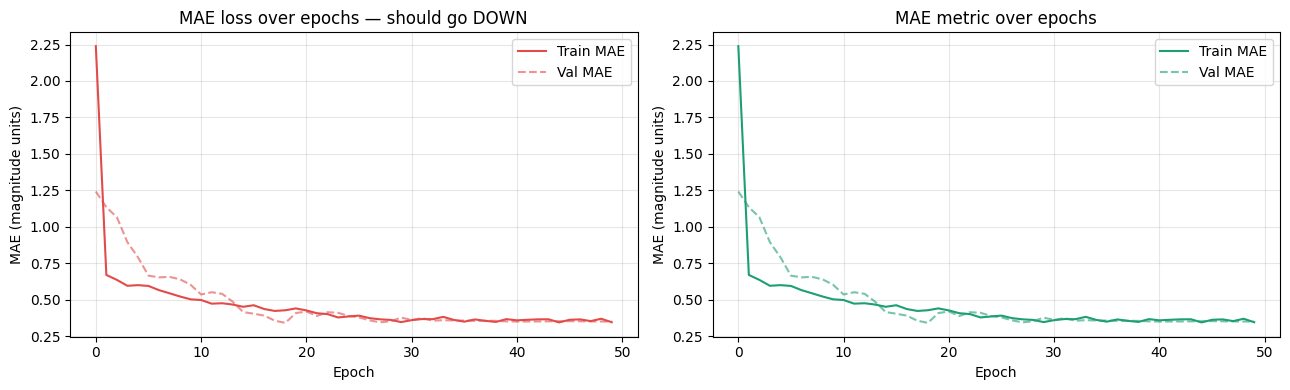

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],
         label='Train MAE', color='#E24B4A')
ax1.plot(history.history['val_loss'],
         label='Val MAE',   color='#E24B4A', linestyle='--', alpha=0.6)
ax1.set_title('MAE loss over epochs — should go DOWN')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MAE (magnitude units)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'],
         label='Train MAE', color='#1D9E75')
ax2.plot(history.history['val_mae'],
         label='Val MAE',   color='#1D9E75', linestyle='--', alpha=0.6)
ax2.set_title('MAE metric over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE (magnitude units)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()